# **NewYork crash analysis**

Ebben a notebookban egy NewYork-i baleseteket tartalmazó adathalmazt fogok vizsgálni.
Első lépésként, letöltöm az adatokat. Ezt kódból teszem meg, mert ezt az adathalmazt gyakran frissítik és így elkerülhető, hogy mindig manuálisan kelljen ezt letölteni a [weboldalról](https://catalog.data.gov/dataset/motor-vehicle-collisions-crashes). 

In [1]:
download = False

if (download):
    import requests
    url = 'https://data.cityofnewyork.us/api/views/h9gi-nx95/rows.csv?accessType=DOWNLOAD'
    query_parameters = {"downloadformat": "csv"}
    response = requests.get(url,params=query_parameters)
    if response.ok:
        with open("motor_vehicle_crashes.csv", mode="wb") as file:
            file.write(response.content)
        print("Download successful!")
    else:
        print("Download failed!")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sb
import datetime

# **Az adathalmaz szöveges bemutatása**

A sorok ütközéseket jegyeznek fel. Egy esemény akkor kerül be az adathalmazba, ha egy személyi sérülés történik, vagy 1000$-nál nagyob kár keletkezik.

A balesetekről összegyűjtött adatok:
- Dátum
- Idő
- Város
- ZIP kód
- Szélességi fok
- Hosszúsági fok
- Helyszín (long., lat.)
- Utca
- Legközelebbi kereztező utca
- Cím
- Megérült emberek száma
- Elhalálozott emberek száma
- Megérült gyalogosok száma
- Elhalálozott gyalogosok száma
- Megérült kerékpárosok száma
- Elhalálozott kerékpárosok száma
- Megérült motorosok száma
- Elhalálozott motorosok száma
- Ok jármű 1
- Ok jármű 2
- Ok jármű 3
- Ok jármű 4
- Ok jármű 5
- Id (egyedi)
- Jármű 1 típus
- Jármű 2 típus
- Jármű 3 típus
- Jármű 4 típus
- Jármű 5 típus

A lehetséges jármű típusok: ATV, bicycle,  car/suv, ebike, escooter, truck/bus, motorcycle, other

##### Segéd adatok

A hipotéziseim vizsgálatázhoz kerestem egy segéd adathalmazt, ami a NewYork-i közlekedési módok használati számát tartalmazza kerületre lebontva. Az adathalmaz [ezen a linken](https://a816-dohbesp.nyc.gov/IndicatorPublic/data-explorer/walking-driving-and-cycling/?id=2415#display=summary) elérhető.

Ebből az adathalmazból a számomra fontos oszlopok a biciklit, gépjárművet, tömegközlekedést használó, illetve a gyalog közlekedő emberek száma. Ezek az adatok évekre és kerületekre vannak lebontva.

Sajnos ezek az adatok csak 2021-ig lettek frissítve, emiatt egyes hipotéziseim csak eddig az évig fogom tudni vizsgálni.

# **A problémakör és az elemzés célja**

Az alapvető célja ennek a feladatnak, hogy gyakorlatot szerezzek egy adathallmazzal való munkában.

Három fő dologot szeretnék elérni. Szeretném megismerni a használt adathalmazt, az adatok eloszlását, szórását és más mutatók használatával. Meg szeretném találni a főbb összefüggéseket a vizsgált adatok között. A tanult információ felhasználásával egy predikciós modellt illeszteni az adatokra, ami valamilyen hasznos jóslást tud számomra elvégezni.

# **Kezdeti hipotézisek**

1. Az aktuális hónap, vagy évszak nem befolyásolja a balesetek számát (nullhipotézis).
2. A COVID járvány hatására jelentősen kevesebb lesz a balesetek száma, viszont ez 2022 után ismét meg fog emelkedni.
3. A karambolok és a gépjárművel közlekedő emberek aránya azonos minden kerületben.

A modellem azt fogja prediktálni, hogy melyik kerületben történt a baleset. Ez azért is hasznos, mert számos adatpontnál hiányzik a kerület oszlop értéke.

# **EDA**

## **Az adatszerkezet beolvasása és megismerése**

In [3]:
# adatok betoltese
df = pd.read_csv('motor_vehicle_crashes.csv')
df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_30352\3903960096.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('motor_vehicle_crashes.csv')


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230.0,40.62179,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,06/29/2022,6:55,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,09/21/2022,13:21,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN


### **Az adathalmaz általános tulajdonságai**

In [4]:
# adathalmaz mérete
df.shape

(2223272, 29)

In [5]:
# oszlopok
df.columns

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME',
       'OFF STREET NAME', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3',
       'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5',
       'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
       'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5'],
      dtype='object')

In [6]:
# oszloptípusok
df.dtypes

CRASH DATE                        object
CRASH TIME                        object
BOROUGH                           object
ZIP CODE                          object
LATITUDE                         float64
LONGITUDE                        float64
LOCATION                          object
ON STREET NAME                    object
CROSS STREET NAME                 object
OFF STREET NAME                   object
NUMBER OF PERSONS INJURED        float64
NUMBER OF PERSONS KILLED         float64
NUMBER OF PEDESTRIANS INJURED      int64
NUMBER OF PEDESTRIANS KILLED       int64
NUMBER OF CYCLIST INJURED          int64
NUMBER OF CYCLIST KILLED           int64
NUMBER OF MOTORIST INJURED         int64
NUMBER OF MOTORIST KILLED          int64
CONTRIBUTING FACTOR VEHICLE 1     object
CONTRIBUTING FACTOR VEHICLE 2     object
CONTRIBUTING FACTOR VEHICLE 3     object
CONTRIBUTING FACTOR VEHICLE 4     object
CONTRIBUTING FACTOR VEHICLE 5     object
COLLISION_ID                       int64
VEHICLE TYPE COD

### ***A duplikátumok vizsgálata***

Ha heylesen lett létrehozva és kezelve az adathalmaz, akkor mivel a COLLISION_ID mező egyedi emiatt nem szabad duplikátumoknak léteznie és látható, hogy ez így is van.

In [7]:
df[df.duplicated()]

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5


### ***A mezők megszámolása***

In [8]:
df.count()

CRASH DATE                       2223272
CRASH TIME                       2223272
BOROUGH                          1542452
ZIP CODE                         1542175
LATITUDE                         1982890
LONGITUDE                        1982890
LOCATION                         1982890
ON STREET NAME                   1738705
CROSS STREET NAME                1373636
OFF STREET NAME                   392193
NUMBER OF PERSONS INJURED        2223254
NUMBER OF PERSONS KILLED         2223241
NUMBER OF PEDESTRIANS INJURED    2223272
NUMBER OF PEDESTRIANS KILLED     2223272
NUMBER OF CYCLIST INJURED        2223272
NUMBER OF CYCLIST KILLED         2223272
NUMBER OF MOTORIST INJURED       2223272
NUMBER OF MOTORIST KILLED        2223272
CONTRIBUTING FACTOR VEHICLE 1    2215404
CONTRIBUTING FACTOR VEHICLE 2    1866060
CONTRIBUTING FACTOR VEHICLE 3     160881
CONTRIBUTING FACTOR VEHICLE 4      36727
CONTRIBUTING FACTOR VEHICLE 5      10065
COLLISION_ID                     2223272
VEHICLE TYPE COD

In [9]:
df.isnull().sum()

CRASH DATE                             0
CRASH TIME                             0
BOROUGH                           680820
ZIP CODE                          681097
LATITUDE                          240382
LONGITUDE                         240382
LOCATION                          240382
ON STREET NAME                    484567
CROSS STREET NAME                 849636
OFF STREET NAME                  1831079
NUMBER OF PERSONS INJURED             18
NUMBER OF PERSONS KILLED              31
NUMBER OF PEDESTRIANS INJURED          0
NUMBER OF PEDESTRIANS KILLED           0
NUMBER OF CYCLIST INJURED              0
NUMBER OF CYCLIST KILLED               0
NUMBER OF MOTORIST INJURED             0
NUMBER OF MOTORIST KILLED              0
CONTRIBUTING FACTOR VEHICLE 1       7868
CONTRIBUTING FACTOR VEHICLE 2     357212
CONTRIBUTING FACTOR VEHICLE 3    2062391
CONTRIBUTING FACTOR VEHICLE 4    2186545
CONTRIBUTING FACTOR VEHICLE 5    2213207
COLLISION_ID                           0
VEHICLE TYPE COD

In [10]:
df.isnull().sum() / df.shape[0] * 100

CRASH DATE                        0.000000
CRASH TIME                        0.000000
BOROUGH                          30.622434
ZIP CODE                         30.634893
LATITUDE                         10.812082
LONGITUDE                        10.812082
LOCATION                         10.812082
ON STREET NAME                   21.795219
CROSS STREET NAME                38.215567
OFF STREET NAME                  82.359648
NUMBER OF PERSONS INJURED         0.000810
NUMBER OF PERSONS KILLED          0.001394
NUMBER OF PEDESTRIANS INJURED     0.000000
NUMBER OF PEDESTRIANS KILLED      0.000000
NUMBER OF CYCLIST INJURED         0.000000
NUMBER OF CYCLIST KILLED          0.000000
NUMBER OF MOTORIST INJURED        0.000000
NUMBER OF MOTORIST KILLED         0.000000
CONTRIBUTING FACTOR VEHICLE 1     0.353893
CONTRIBUTING FACTOR VEHICLE 2    16.066950
CONTRIBUTING FACTOR VEHICLE 3    92.763773
CONTRIBUTING FACTOR VEHICLE 4    98.348065
CONTRIBUTING FACTOR VEHICLE 5    99.547289
COLLISION_I

Látható, hogy több oszlopnak is jelentős része üres, de láthatók összefüggések, például, ha a város értéke üres, akkor a zip kód is hiányzik, illetve, ha a pozíció üres, akkor a hosszúsági és szélességi fok is az lesz.

A balesetek címe több mint a bejegyzések 80%-nál hiányzik, de a többi címhez kapcsolódó attribútum is igen hiányos (20-30%).

A balesetben résztvető járművekhez köthető oszlopokban a nagy hiányráta könnyen magyarázható, mivel a több járművet érintő balesetek ritkábbak.

## **A jellemzők vizsgálata és ábrázolása**

### **Numerikus adatok**

Több szám értékű attribútumra is értelmetlenek a statisztikati mutatók, például a hosszúsági és a szélességi fok, ezért manuálisan kiválasztottam a hasznos oszlopokat. Ezek azok az oszlopok, amik a sérült személyek számát írják le.

In [11]:
numCols = df.filter(regex=("NUMBER*")).copy(deep=True)
# Drop the insignificant number of rows with nulls
numCols = numCols.dropna()
# Convert floats to ints for easier data usage
numCols['NUMBER OF PERSONS INJURED'] = pd.to_numeric(numCols['NUMBER OF PERSONS INJURED'], downcast='integer', errors='coerce')
numCols['NUMBER OF PERSONS KILLED'] = pd.to_numeric(numCols['NUMBER OF PERSONS KILLED'], downcast='integer', errors='coerce')
numCols.describe()

,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED
count,2.223235e+06,2.223235e+06,2.223235e+06,2.223235e+06,2.223235e+06,2.223235e+06,2.223235e+06,2.223235e+06
mean,3.285276e-01,1.584178e-03,5.967835e-02,7.844425e-04,2.922588e-02,1.259426e-04,2.349729e-01,6.441064e-04
std,7.150637e-01,4.204622e-02,2.502129e-01,2.863234e-02,1.707176e-01,1.126172e-02,6.762181e-01,2.775850e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,4.300000e+01,8.000000e+00,2.700000e+01,6.000000e+00,4.000000e+00,2.000000e+00,4.300000e+01,5.000000e+00


In [12]:
# ferdeség
print(numCols.skew())

NUMBER OF PERSONS INJURED         4.084825
NUMBER OF PERSONS KILLED         32.599171
NUMBER OF PEDESTRIANS INJURED     5.422908
NUMBER OF PEDESTRIANS KILLED     40.809843
NUMBER OF CYCLIST INJURED         5.837601
NUMBER OF CYCLIST KILLED         90.033681
NUMBER OF MOTORIST INJURED        4.936690
NUMBER OF MOTORIST KILLED        53.008646
dtype: float64


In [13]:
# csúcsosság
print(numCols.kurt())

NUMBER OF PERSONS INJURED          46.669667
NUMBER OF PERSONS KILLED         1760.515175
NUMBER OF PEDESTRIANS INJURED     112.313240
NUMBER OF PEDESTRIANS KILLED     2393.792303
NUMBER OF CYCLIST INJURED          34.186492
NUMBER OF CYCLIST KILLED         8214.339695
NUMBER OF MOTORIST INJURED         58.091047
NUMBER OF MOTORIST KILLED        3908.799174
dtype: float64


#### ***Az eloszlások vizsgálata***

<Figure size 1000x700 with 0 Axes>

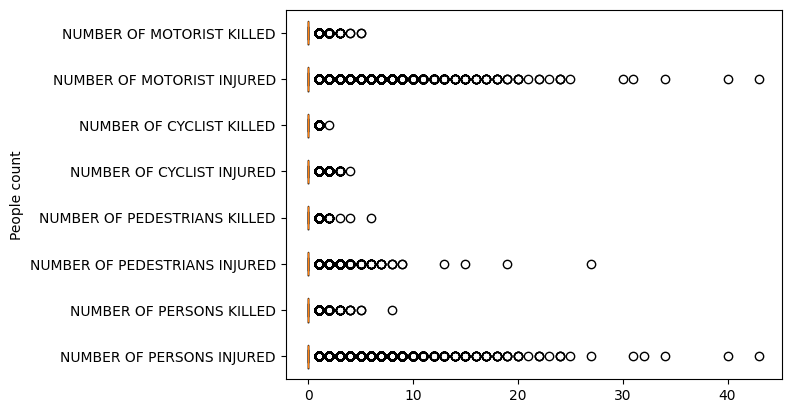

In [14]:
# Boxplotok
cols = numCols.columns
fig = plt.figure(figsize=(10, 7))
fig, ax = plt.subplots()
ax.set_ylabel("People count")
bplot = ax.boxplot(numCols, tick_labels=cols, orientation='horizontal')
plt.show()

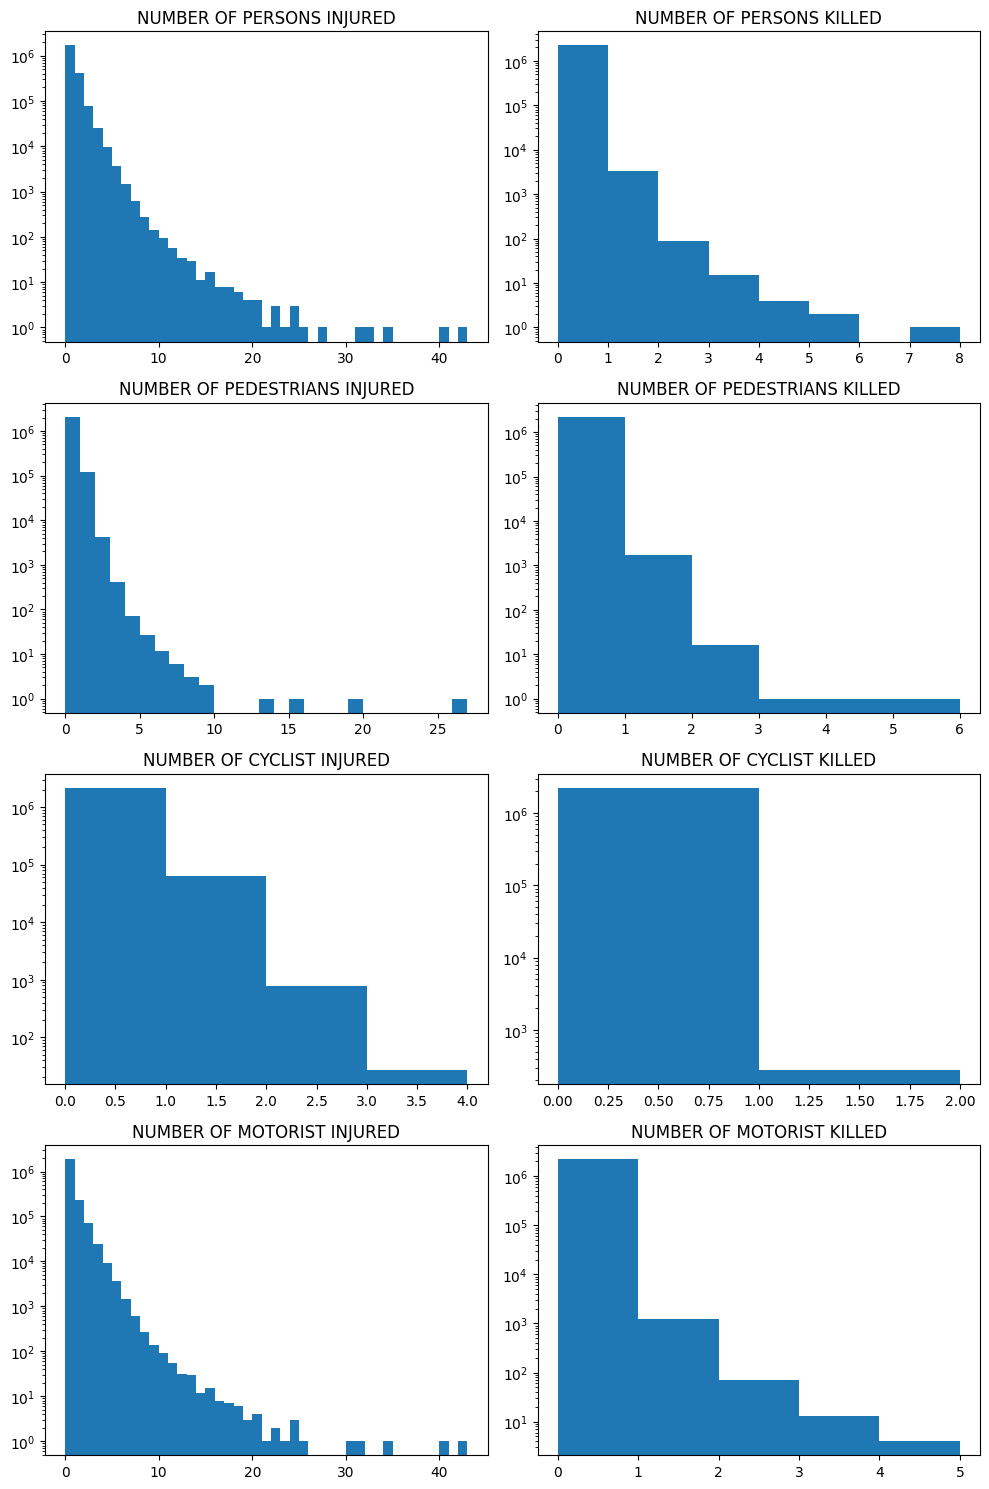

<Figure size 3000x2000 with 0 Axes>

In [15]:
# Hisztogrammok
fig, ((ax0, ax1), (ax2, ax3), (ax4, ax5), (ax6, ax7)) = plt.subplots(nrows=4, ncols=2, figsize = (10,15))
plt.figure(figsize = (30,20))

plots = [ax0, ax1, ax2, ax3, ax4, ax5, ax6, ax7]

for i, col in enumerate(cols):
    plot = plots[i]
    plot.hist(numCols[col], numCols[col].max(), histtype='bar')
    plot.set_yscale('log')
    #plot.set_xscale('log')
    plot.set_title(col)
    
fig.tight_layout()
plt.show()


A hisztogrammok sokkal informálóbbak. Az y tengely értékét logaritmikus skálára állítottam és így látható egy csökkenő eloszlás.

#### **Dátumok**

Érdemes még megvizsgálni a dátumokat, hogy lássuk van e valamilyen anomália, amiből következtethetünk az adatgyűjtés minőségére. Ehhez át kell alakítani a szövegként tárolt dátumokat egy numerikus formátummá.

In [16]:
dates = df.filter(regex="(CRASH DATE)|(CRASH TIME)").copy(deep=True)

# Convert CRASH DATE column from object to datetime64
dates['CRASH DATE'] = pd.to_datetime(
    df['CRASH DATE'],
    format='%m/%d/%Y',
    errors='coerce'
)

# Convert the CRASH TIME column from stings to timedelta64
padded_time = df['CRASH TIME'].str.replace(r'^(\d:)', r'0\1', regex=True) # Pad out the hours with a leading 0 to match pandas time format
timedelta_time = pd.to_datetime(
    padded_time,
    format='%H:%M',
    errors='coerce'
)
dates['CRASH TIME'] = timedelta_time - timedelta_time.dt.normalize() # make the days 0

In [17]:
dates.describe()

,CRASH DATE,CRASH TIME
count,2223272,2223272
mean,2018-01-17 01:06:06.374604800,0 days 13:34:54.553567894
min,2012-07-01 00:00:00,0 days 00:00:00
25%,2015-03-24 00:00:00,0 days 09:35:00
50%,2017-09-04 00:00:00,0 days 14:15:00
75%,2020-03-16 00:00:00,0 days 18:00:00
max,2025-11-23 00:00:00,0 days 23:59:00
std,NaN,0 days 05:47:58.105985545


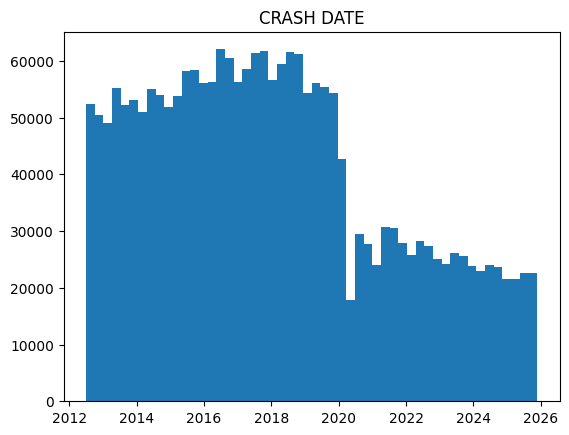

In [18]:
# Dátum hisztogramm
plt.rcParams["figure.figsize"] = plt.rcParamsDefault["figure.figsize"]
plt.hist(dates['CRASH DATE'], 52, histtype='bar')
plt.title('CRASH DATE')
plt.show()

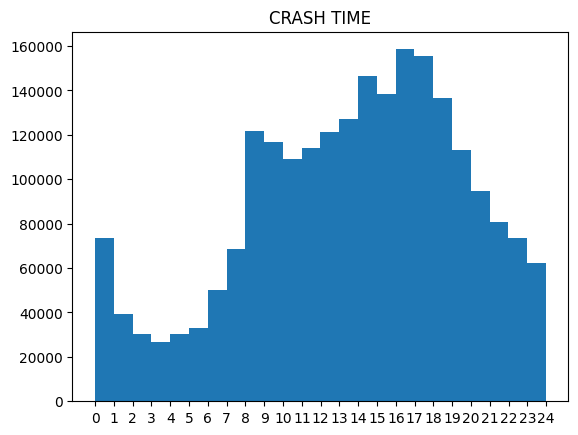

In [19]:
# Időpont hisztogramm
dates['CRASH TIME OF DAY'] = dates['CRASH TIME'].dt.total_seconds() / 3600
plt.hist(dates['CRASH TIME OF DAY'], 24, histtype='bar')
plt.title('CRASH TIME')
plt.xticks(range(0,25))
plt.show()

Látszik, hogy csúcsforgalomban történik a legtöbb baleset. Két lokális maximum van, reggel 8 és délután 5, amikor az emberek munkába és munkából közlekednek.

### **Kategorikus változók vizsgálata**

#### ***A kategóriák száma***

In [20]:
# Segéd data frame a kategórikus változók viszgáltához 
cat_df = pd.DataFrame({'UNIQUE': df.select_dtypes(include=['object']).nunique(),
                       'COUNT': df.select_dtypes(include=['object']).count(),
                       'NULLS': df.select_dtypes(include=['object']).isnull().sum()})

cat_df

,UNIQUE,COUNT,NULLS
CRASH DATE,4894,2223272,0
CRASH TIME,1440,2223272,0
BOROUGH,5,1542452,680820
ZIP CODE,436,1542175,681097
LOCATION,334866,1982890,240382
ON STREET NAME,22761,1738705,484567
CROSS STREET NAME,24873,1373636,849636
OFF STREET NAME,260100,392193,1831079
CONTRIBUTING FACTOR VEHICLE 1,61,2215404,7868
CONTRIBUTING FACTOR VEHICLE 2,61,1866060,357212


Több fura dolog is látható. A location oszlopban az egyedi értékek száma sokkal kevesebb, mint ahány bejegyzés van, annak ellenére, hogy ez koordinátákat tárol.

A jármű típus kód annak ellenére, hogy az adathalmaz leírásában csak 8 legális értéket tűntettek fel itt több mint 2000 egyedi értékkel rendelkezik. Ezt meg kell vizsgálni.

Ezzel szemben a okozó tényezőkből csupán 61 típus van, így ezzel sokkal könnyebb lesz dolgozni.

##### **Az járműtípusok vizsgálata**

In [21]:
vcodes = df.filter(regex="VEHICLE TYPE CODE*").copy(deep=True)
vcodes

,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,Sedan,Sedan,NaN,NaN,NaN
1,Sedan,NaN,NaN,NaN,NaN
2,Moped,Sedan,Sedan,NaN,NaN
3,Sedan,Pick-up Truck,NaN,NaN,NaN
4,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2223267,Tractor Truck Diesel,Sedan,NaN,NaN,NaN
2223268,Sedan,Sedan,NaN,NaN,NaN
2223269,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
2223270,Tractor Truck Diesel,NaN,NaN,NaN,NaN


In [22]:
print(vcodes['VEHICLE TYPE CODE 1'].nunique())
vcodes['VEHICLE TYPE CODE 1'].value_counts().head(25)

1841


VEHICLE TYPE CODE 1
Sedan                                  643102
Station Wagon/Sport Utility Vehicle    503620
PASSENGER VEHICLE                      416206
SPORT UTILITY / STATION WAGON          180291
Taxi                                    55928
4 dr sedan                              40187
Pick-up Truck                           38309
TAXI                                    31911
Box Truck                               26595
VAN                                     25266
Bus                                     24350
OTHER                                   22968
UNKNOWN                                 19940
Bike                                    18150
LARGE COM VEH(6 OR MORE TIRES)          14397
BUS                                     13993
SMALL COM VEH(4 TIRES)                  13216
PICK-UP TRUCK                           11505
Tractor Truck Diesel                    11348
LIVERY VEHICLE                          10481
Motorcycle                               9881
Van           

Sajnos a jármű típusok rengeteg különböző módon vannak leírva, aminek egy lehetséges oka, hogy az idő során ezek a kategóriák változtak, vagy kézzel bevitt értékek. Első sorban a kis és nagy betűk konszolidálása, majd az azonos kategóriák különböző megnevezésének az egységesítését kéne elvégezni.

#### ***Okok vizsgálata***

In [23]:
factors = df.filter(regex="CONTRI.*").copy(deep=True)
factors

,CONTRIBUTING FACTOR VEHICLE 1,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5
0,Aggressive Driving/Road Rage,Unspecified,NaN,NaN,NaN
1,Pavement Slippery,NaN,NaN,NaN,NaN
2,Unspecified,Unspecified,Unspecified,NaN,NaN
3,Following Too Closely,Unspecified,NaN,NaN,NaN
4,Passing Too Closely,Unspecified,NaN,NaN,NaN
...,...,...,...,...,...
2223267,Unspecified,Unspecified,NaN,NaN,NaN
2223268,Passing or Lane Usage Improper,Unsafe Speed,NaN,NaN,NaN
2223269,Driver Inattention/Distraction,NaN,NaN,NaN,NaN
2223270,Oversized Vehicle,NaN,NaN,NaN,NaN


In [24]:
print(factors['CONTRIBUTING FACTOR VEHICLE 1'].unique())

['Aggressive Driving/Road Rage' 'Pavement Slippery' 'Unspecified'
 'Following Too Closely' 'Passing Too Closely'
 'Failure to Yield Right-of-Way' nan 'Driver Inexperience'
 'Passing or Lane Usage Improper' 'Turning Improperly'
 'Unsafe Lane Changing' 'Unsafe Speed' 'Reaction to Uninvolved Vehicle'
 'Steering Failure' 'Traffic Control Disregarded' 'Other Vehicular'
 'Driver Inattention/Distraction' 'Accelerator Defective'
 'Oversized Vehicle'
 'Pedestrian/Bicyclist/Other Pedestrian Error/Confusion'
 'Alcohol Involvement' 'View Obstructed/Limited' 'Illnes'
 'Lost Consciousness' 'Brakes Defective' 'Backing Unsafely' 'Glare'
 'Passenger Distraction' 'Fell Asleep' 'Obstruction/Debris'
 'Tinted Windows' 'Animals Action' 'Drugs (illegal)' 'Pavement Defective'
 'Other Lighting Defects' 'Outside Car Distraction'
 'Driverless/Runaway Vehicle' 'Tire Failure/Inadequate' 'Fatigued/Drowsy'
 'Headlights Defective' 'Failure to Keep Right' 'Physical Disability'
 'Eating or Drinking' 'Cell Phone (hands-

In [25]:
print(factors['CONTRIBUTING FACTOR VEHICLE 1'].nunique())
factors['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().head(25)

61


CONTRIBUTING FACTOR VEHICLE 1
Unspecified                                              744015
Driver Inattention/Distraction                           451419
Failure to Yield Right-of-Way                            133180
Following Too Closely                                    119395
Backing Unsafely                                          81127
Other Vehicular                                           69507
Passing or Lane Usage Improper                            63814
Passing Too Closely                                       56499
Turning Improperly                                        54699
Fatigued/Drowsy                                           47559
Unsafe Lane Changing                                      43836
Traffic Control Disregarded                               40885
Driver Inexperience                                       35820
Unsafe Speed                                              34285
Alcohol Involvement                                       25566
Reaction t

Az okokbó csak 61 egyedi érték van, ezért ezzel sokkal kevesebb gond lesz, de látható hogy itt is található pár furcsa érték, mint a 80 és az 1, illetve vannak elírások, amik egyébként azonos okok lennének. Ezeket majd javítom.

## **A változók közötti összefüggések**

### **Korrelációs mátrix**

In [26]:
corr = df.filter(regex='NUMBER').corr()
corr

,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED
NUMBER OF PERSONS INJURED,1.000000,0.013568,0.272428,0.001912,0.172563,-0.001619,0.903981,0.019477
NUMBER OF PERSONS KILLED,0.013568,1.000000,0.005636,0.689793,-0.004570,0.280752,0.013469,0.660442
NUMBER OF PEDESTRIANS INJURED,0.272428,0.005636,1.000000,0.011798,-0.035188,0.000365,-0.071708,-0.003527
NUMBER OF PEDESTRIANS KILLED,0.001912,0.689793,0.011798,1.000000,-0.003310,0.019223,-0.001343,0.005590
NUMBER OF CYCLIST INJURED,0.172563,-0.004570,-0.035188,-0.003310,1.000000,0.001595,-0.056032,-0.003972
NUMBER OF CYCLIST KILLED,-0.001619,0.280752,0.000365,0.019223,0.001595,1.000000,-0.002173,-0.000259
NUMBER OF MOTORIST INJURED,0.903981,0.013469,-0.071708,-0.001343,-0.056032,-0.002173,1.000000,0.023064
NUMBER OF MOTORIST KILLED,0.019477,0.660442,-0.003527,0.005590,-0.003972,-0.000259,0.023064,1.000000


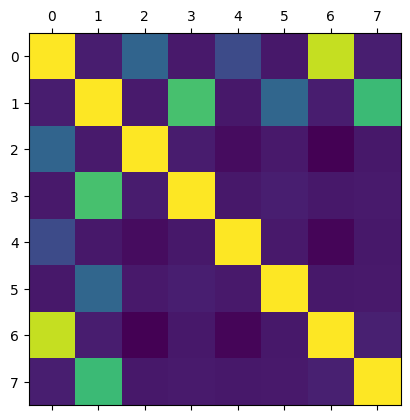

In [27]:
plt.matshow(corr)

3 oszlop között látható jelentős pozitív korreláció, a halott emberek és a halott motorosok, a halott emberek és a gyalogosok és a sérült emberek és a sérült motorosok. Ebből arra lehet következtetni, hogy a motorosok sérülnek meg a leggyakrabban, illetve gyalogosok halnak meg a leggyakrabban, akiket közel követnek a motorosok.

Gyenge negatív korreláció van a sérült motorosok és sérült gyalogosok és a sérült biciklisek számával. Ebből az következik, hogy motorosok ritkábban ütköznek gyalogossal és biciklissel.

# **Adattisztítás és előkészítés**

### **A numerikus adatok tisztítása és új segédoszlopok hozzáadása**

In [28]:
df_cleaned = df.copy(deep=True)

df_cleaned['CRASH DATE'] = dates['CRASH DATE']
df_cleaned['CRASH TIME'] = dates['CRASH TIME']
df_cleaned['CRASH TIME OF DAY'] = dates['CRASH TIME OF DAY']

df_cleaned = df_cleaned.dropna(subset=['NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED'])
df_cleaned['NUMBER OF PERSONS INJURED'] = numCols['NUMBER OF PERSONS INJURED']
df_cleaned['NUMBER OF PERSONS KILLED'] = numCols['NUMBER OF PERSONS KILLED']

df_cleaned.dtypes

CRASH DATE                        datetime64[ns]
CRASH TIME                       timedelta64[ns]
BOROUGH                                   object
ZIP CODE                                  object
LATITUDE                                 float64
LONGITUDE                                float64
LOCATION                                  object
ON STREET NAME                            object
CROSS STREET NAME                         object
OFF STREET NAME                           object
NUMBER OF PERSONS INJURED                   int8
NUMBER OF PERSONS KILLED                    int8
NUMBER OF PEDESTRIANS INJURED              int64
NUMBER OF PEDESTRIANS KILLED               int64
NUMBER OF CYCLIST INJURED                  int64
NUMBER OF CYCLIST KILLED                   int64
NUMBER OF MOTORIST INJURED                 int64
NUMBER OF MOTORIST KILLED                  int64
CONTRIBUTING FACTOR VEHICLE 1             object
CONTRIBUTING FACTOR VEHICLE 2             object
CONTRIBUTING FACTOR 

### ***A kategorikus adatok tisztítása***

#### ***Jármű kódok***

Az EDA-ban észrevettem, hogy rendkívül sok egyedi kód van, itt ezt javítom.

Létrehozok egy segéd data framet, amin elvégzem a módosításokat.

In [29]:
# Nagybetűsítés és a felesleges white space levágása
vcodes = vcodes.apply(lambda x: x.str.upper().str.strip())

In [30]:
vcodes = vcodes.apply(lambda x: x.replace(r'.*SEDAN.*', value='SEDAN', regex=True))
vcodes = vcodes.apply(lambda x: x.replace(r'.*VAN.*', value='VAN', regex=True))
vcodes = vcodes.apply(lambda x: x.replace(r'.*UTILITY.*', value='STATION WAGON / SPORT UTILITY', regex=True))
vcodes = vcodes.apply(lambda x: x.replace(r'.*E-BIK.*', value='E-BIKE', regex=True))
vcodes = vcodes.apply(lambda x: x.replace(r'.*E-SCO.*', value='E-SCOOTER', regex=True))
vcodes = vcodes.apply(lambda x: x.replace(r'.*FIRE.*', value='FIRE TRUCK', regex=True))
vcodes = vcodes.apply(lambda x: x.replace(r'.*AMB.*', value='AMBULANCE', regex=True))
vcodes = vcodes.apply(lambda x: x.replace(r'.*COM.*', value='COMMERCIAL', regex=True))
vcodes = vcodes.apply(lambda x: x.replace(r'.*PIC.*', value='PICK-UP TRUCK', regex=True))
vcodes = vcodes.apply(lambda x: x.replace(r'.*DUM.*', value='DUMP TRUCK', regex=True))
vcodes = vcodes.apply(lambda x: x.replace(r'.*GAR.*', value='GARBAGE TRUCK', regex=True))

In [31]:
# Regex ellenőrzés a kód egységesítéshez
reg_sel = vcodes[vcodes['VEHICLE TYPE CODE 1'].str.contains(r'.*DUMB.*', regex = True, na = False)]['VEHICLE TYPE CODE 1']
print(reg_sel.nunique())
print(reg_sel.value_counts())

0
Series([], Name: count, dtype: int64)


Pár könnyen konszolidálható értéket javítottam a fenti kóddal, ahol mindent nagybetűre változtatok és regex kifejezésekkel a gyakori típusok különböző megnevezéseit egységesítem.

In [32]:
print(vcodes['VEHICLE TYPE CODE 1'].nunique())
vcodes['VEHICLE TYPE CODE 1'].value_counts().head(5)

1117


VEHICLE TYPE CODE 1
SEDAN                            685953
STATION WAGON / SPORT UTILITY    683964
PASSENGER VEHICLE                416206
TAXI                              87843
PICK-UP TRUCK                     50087
Name: count, dtype: int64

Ezzel sikerült csökkenteni az egyedi értékek számát 1841-ről 1117-re.

In [33]:
# Segéd data frame
temp = pd.DataFrame({'UNIQUE': vcodes['VEHICLE TYPE CODE 1'].value_counts(),
    'PERCENTAGE': vcodes['VEHICLE TYPE CODE 1'].value_counts() / vcodes['VEHICLE TYPE CODE 1'].count()})
pd.set_option('display.float_format', lambda x: '%.5f' % x)
print(temp.head(25)['PERCENTAGE'].sum())
temp.head(5)

0.9916463795616536


,UNIQUE,PERCENTAGE
VEHICLE TYPE CODE 1,,
SEDAN,685953,0.31080
STATION WAGON / SPORT UTILITY,683964,0.30990
PASSENGER VEHICLE,416206,0.18858
TAXI,87843,0.03980
PICK-UP TRUCK,50087,0.02269


Látható, hogy a sorok több mint 99%-a a top 25 kategóriából származik, viszont mivel az ennél kevésbé gyakori kategóriákhoz is több ezer sor tartozik ezeket nem szeretném törötlni.

In [34]:
temp[temp['UNIQUE'] == 1].count()

UNIQUE        677
PERCENTAGE    677
dtype: int64

Megvizsgáltam mennyi olyan típus van amiből csak bejegyzés van. Mivel ezek vagy nem létező kategóriák, vagy elírások, amik nehez javíthatók és több mint 700 van belőlük ezek törlésével jelnetősen javulna az adathalmaz minősége.

In [35]:
threshold = 100
print(temp.count() - temp[temp['UNIQUE'] <= threshold].count())
print(temp[temp['UNIQUE'] <= threshold].head(20))

UNIQUE        54
PERCENTAGE    54
dtype: int64
                     UNIQUE  PERCENTAGE
VEHICLE TYPE CODE 1                    
USPS                     89     0.00004
UNKNO                    86     0.00004
SCHOO                    84     0.00004
OPEN BODY                83     0.00004
UNK                      80     0.00004
DELIV                    77     0.00003
BULK AGRICULTURE         76     0.00003
TOW T                    74     0.00003
BOX T                    66     0.00003
UTILI                    65     0.00003
SCOOT                    63     0.00003
DELV                     62     0.00003
PALLET                   53     0.00002
PAS                      52     0.00002
FORKL                    47     0.00002
UTIL                     44     0.00002
ELECT                    44     0.00002
FDNY TRUCK               43     0.00002
MINIBIKE                 40     0.00002
LUNCH WAGON              40     0.00002


A fenti adatok alaján úgy döntök, hogy OTHER-re állítom azokat a kategóriákat, amiknél kevesebb mint 100 bejegyzés van. Bár ezzel veszítek némi adatot csupán 54 kategóriám marad az eredeti 1841-hez képest.

In [36]:
temp = temp.drop(temp[temp['UNIQUE'] < threshold].index)
temp['PERCENTAGE'].sum()

np.float64(0.9980050447041255)

Az adatok módosítása utána a sorok 99.8%-a eredeti maradt meg.

In [37]:
# Az adatok módosítása a vcodes data framen

valid_codes = list(temp.index)

#vcodes.loc[~vcodes['VEHICLE TYPE CODE 1'].isin(valid_codes), 'VEHICLE TYPE CODE 1'] = 'OTHER'
#vcodes.loc[~vcodes['VEHICLE TYPE CODE 2'].isin(valid_codes), 'VEHICLE TYPE CODE 2'] = 'OTHER'
#vcodes.loc[~vcodes['VEHICLE TYPE CODE 3'].isin(valid_codes), 'VEHICLE TYPE CODE 3'] = 'OTHER'
#vcodes.loc[~vcodes['VEHICLE TYPE CODE 4'].isin(valid_codes), 'VEHICLE TYPE CODE 4'] = 'OTHER'
#vcodes.loc[~vcodes['VEHICLE TYPE CODE 5'].isin(valid_codes), 'VEHICLE TYPE CODE 5'] = 'OTHER'

# Az invalid kódok OTHER-re cserélése a nan értékek megtartásával
for i in range(1,6):
    vcodes.loc[~vcodes['VEHICLE TYPE CODE ' + str(i)].isin(valid_codes) & (vcodes['VEHICLE TYPE CODE ' + str(i)].notna()), 'VEHICLE TYPE CODE ' + str(i)] = 'OTHER'

vcodes.nunique()

VEHICLE TYPE CODE 1    54
VEHICLE TYPE CODE 2    54
VEHICLE TYPE CODE 3    54
VEHICLE TYPE CODE 4    48
VEHICLE TYPE CODE 5    39
dtype: int64

##### Jármű típisok bar plot

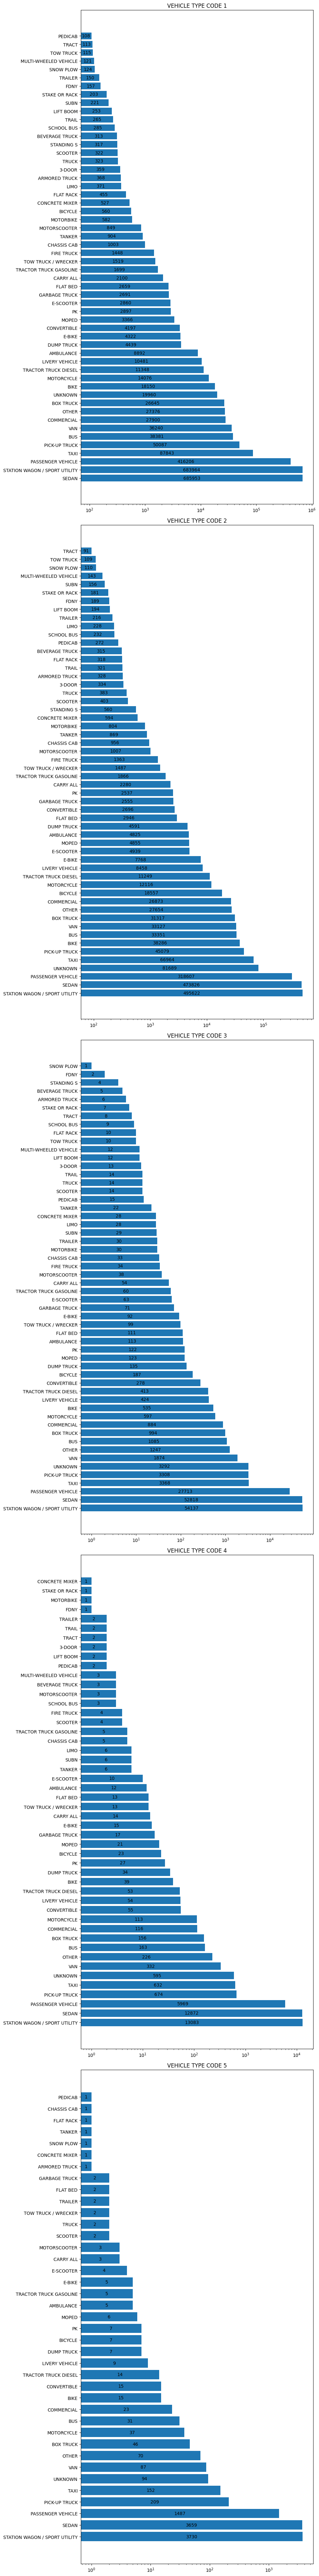

In [38]:
fig, (ax0, ax1, ax2, ax3, ax4) = plt.subplots(nrows=5, ncols=1, figsize = (10, 80))

plots = [ax0, ax1, ax2, ax3, ax4]

cols = vcodes.columns

for i, col in enumerate(cols):
    plot = plots[i]
    bars = plot.barh(vcodes[col].value_counts().index, vcodes[col].value_counts())
    plot.set_xscale('log')
    plot.set_title(col)
    plot.bar_label(bars, label_type='center', color='black')
    
fig.tight_layout()
plt.show()

#### **Balesetet okozó tényezők**

In [39]:
# Nagybetűsítés és a felesleges white space levágása
factors = factors.apply(lambda x: x.str.upper().str.strip())

In [40]:
# Regex segítségével az elírt, de azonos kódokat egységesítettem, illetve a 1 és 80 értéket unspecified-ra állítottam
factors = factors.apply(lambda x: x.replace(r'.*UNINVOLVED VEHICLE.*', value='REACTION TO UNINVOLVED VEHICLE', regex=True))
factors = factors.apply(lambda x: x.replace(r'.*ILLNE.*', value='ILLNESS', regex=True))
factors = factors.apply(lambda x: x.replace(r'1|80', value='UNSPECIFIED', regex=True))

In [41]:
# Regex ellenőrzés a kód egységesítéshez
reg_sel = factors[factors['CONTRIBUTING FACTOR VEHICLE 1'].str.contains(r'1|80', regex = True, na = False)]['CONTRIBUTING FACTOR VEHICLE 1']
print(reg_sel.nunique())
print(reg_sel.value_counts())

0
Series([], Name: count, dtype: int64)


Megtisztítottam az adatokat, egységesítettem a különböző okokat.

##### Kezdeti faktorok barplot

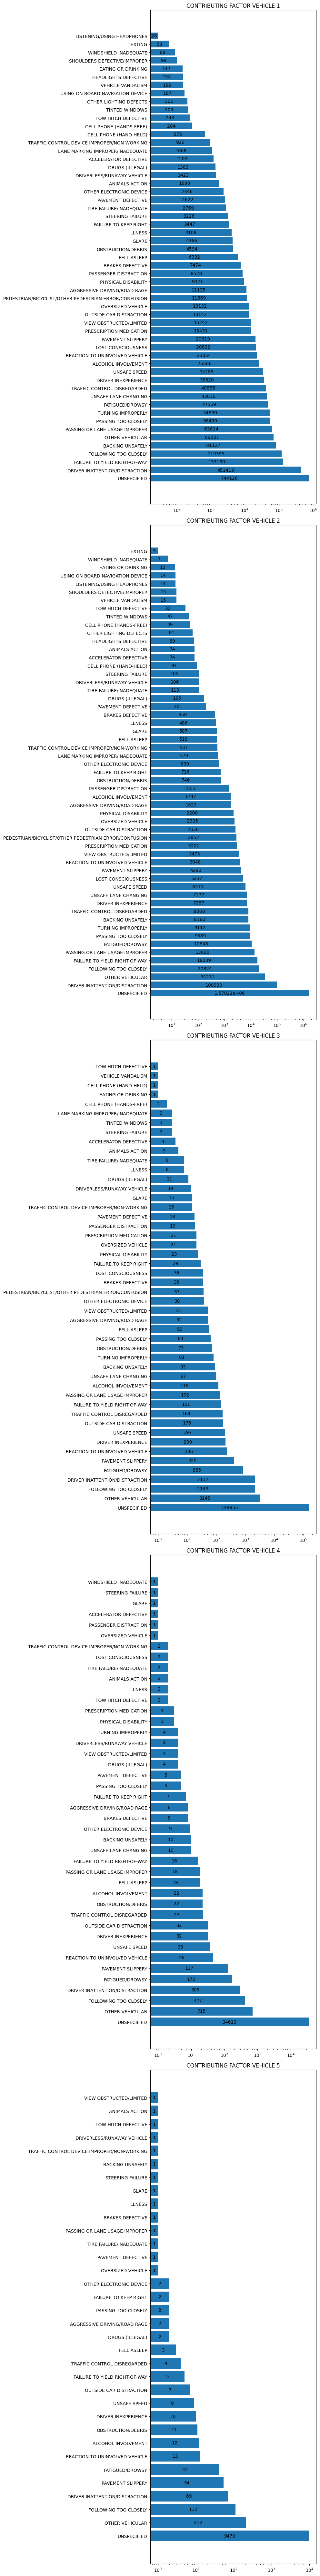

In [42]:
fig, (ax0, ax1, ax2, ax3, ax4) = plt.subplots(nrows=5, ncols=1, figsize = (10, 80))

plots = [ax0, ax1, ax2, ax3, ax4]

cols = factors.columns

for i, col in enumerate(cols):
    plot = plots[i]
    bars = plot.barh(factors[col].value_counts().index, factors[col].value_counts())
    plot.set_xscale('log')
    plot.set_title(col)
    plot.bar_label(bars, label_type='center', color='black')
    
fig.tight_layout()
plt.show()

#### **A javítások átmásolása**

In [43]:
for i in range(1,6):
    df_cleaned['VEHICLE TYPE CODE ' + str(i)] = vcodes['VEHICLE TYPE CODE ' + str(i)]
    
for i in range(1, 6):
    df_cleaned['CONTRIBUTING FACTOR VEHICLE ' + str(i)] = factors['CONTRIBUTING FACTOR VEHICLE ' + str(i)]

### **Az idő oszolopok bővítése**

Mivel a hipotéziseim vizsgálását nagyban segítené, ha évekre illetve hónapokra bontva tudnám megnézni a balesetek számát, ezért létrehozok segédoszlopokat ehhez.

In [44]:
df_cleaned['CRASH YEAR'] = df_cleaned['CRASH DATE'].dt.year
df_cleaned['CRASH MONTH'] = df_cleaned['CRASH DATE'].dt.month
df_cleaned['CRASH DAY OF WEEK'] = df_cleaned['CRASH DATE'].dt.dayofweek

Létrehoztam év, hónap és a hét napja oszlopokat, hogy könnyebben lehessen később vizsgálni az összefüggéseket.

### **A segédadatok formázása**

In [45]:
helper_df = pd.read_csv('NYC_Commuting_modes.csv')
helper_df.head()

,TimePeriod,GeoTypeDesc,GeoID,GeoRank,BoroID,Borough,Geography,Area,Bicycle (number),"Car, truck, or van (number)",Public transportation (number),Walked (number),Bicycle (percent),"Car, truck, or van (percent)",Public transportation (percent),Walked (percent)
0,2017-21,Citywide,1,0,-,-,New York City,New York City,"54,919","1,082,647","2,007,988","384,380",1.40000,26.80000,49.70000,9.50000
1,2017-21,Borough,3,1,3,Manhattan,Manhattan,Manhattan,"20,706","67,721","450,560","167,318",2.30000,7.60000,50.80000,18.90000
2,2017-21,Borough,2,1,2,Brooklyn,Brooklyn,Brooklyn,"24,134","274,494","663,716","104,403",2.00000,22.30000,53.80000,8.50000
3,2017-21,Borough,1,1,1,Bronx,Bronx,Bronx,"2,589","164,218","324,274","41,772",0.40000,28.40000,56.10000,7.20000
4,2017-21,Borough,4,1,4,Queens,Queens,Queens,"7,082","437,872","511,929","64,864",0.60000,38.90000,45.50000,5.80000


In [46]:
helper_df = helper_df.drop(['GeoID', 'GeoRank', 'Geography', 'Area'], axis=1)
helper_df = helper_df.apply(lambda x: x.replace(r'.*-', value="20", regex=True))

In [47]:
borough_trans = helper_df[helper_df['GeoTypeDesc'] == 'Borough']
city_trans = helper_df[helper_df['GeoTypeDesc'] == 'Citywide']

In [48]:
borough_trans = borough_trans.drop(['GeoTypeDesc'], axis=1)
borough_trans

,TimePeriod,BoroID,Borough,Bicycle (number),"Car, truck, or van (number)",Public transportation (number),Walked (number),Bicycle (percent),"Car, truck, or van (percent)",Public transportation (percent),Walked (percent)
1,2021,3,Manhattan,"20,706","67,721","450,560","167,318",2.30000,7.60000,50.80000,18.90000
2,2021,2,Brooklyn,"24,134","274,494","663,716","104,403",2.00000,22.30000,53.80000,8.50000
3,2021,1,Bronx,"2,589","164,218","324,274","41,772",0.40000,28.40000,56.10000,7.20000
4,2021,4,Queens,"7,082","437,872","511,929","64,864",0.60000,38.90000,45.50000,5.80000
5,2021,5,Staten Island,408,"138,342","57,509","6,023",0.20000,63.00000,26.20000,2.70000
7,2020,3,Manhattan,"19,786","67,507","480,245","172,404",2.30000,7.70000,54.90000,19.70000
8,2020,2,Brooklyn,"22,710","264,021","682,380","101,009",1.90000,22.40000,57.80000,8.60000
9,2020,1,Bronx,"2,687","163,626","327,933","41,745",0.50000,28.60000,57.40000,7.30000
10,2020,4,Queens,"6,115","419,816","522,598","62,606",0.60000,38.80000,48.20000,5.80000
11,2020,5,Staten Island,350,"135,565","59,684","5,889",0.20000,63.60000,28.00000,2.80000


In [49]:
city_trans = city_trans.drop(['GeoTypeDesc', 'BoroID', 'Borough'], axis=1)
city_trans

,TimePeriod,Bicycle (number),"Car, truck, or van (number)",Public transportation (number),Walked (number),Bicycle (percent),"Car, truck, or van (percent)",Public transportation (percent),Walked (percent)
0,2021,"54,919","1,082,647","2,007,988","384,380",1.40000,26.80000,49.70000,9.50000
6,2020,"51,648","1,050,535","2,072,840","383,653",1.30000,26.80000,52.80000,9.80000
12,2019,"50,272","1,063,173","2,229,452","397,335",1.30000,26.70000,56.00000,10.00000
18,2018,"47,434","1,060,311","2,223,087","392,607",1.20000,26.80000,56.20000,9.90000
24,2017,"47,047","1,057,885","2,247,732","396,134",1.20000,26.60000,56.50000,10.00000
30,2016,"43,955","1,037,311","2,205,425","391,365",1.10000,26.60000,56.60000,10.00000
36,2015,"39,855","1,024,183","2,169,774","390,293",1.00000,26.70000,56.50000,10.20000
42,2014,"37,009","1,015,076","2,113,466","380,414",1.00000,27.00000,56.20000,10.10000
48,2013,"32,879","1,011,758","2,067,531","377,698",0.90000,27.30000,55.90000,10.20000


## **A modellillesztéshez használt adatok előkészítése**

A adataimról leválasztom azokat a sorokat, ahol a kerület oszlop üres.

In [50]:
modell_df = df_cleaned.loc[df_cleaned['BOROUGH'].notna()].copy(deep=True)
modell_df

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5,CRASH TIME OF DAY,CRASH YEAR,CRASH MONTH,CRASH DAY OF WEEK
2,2023-11-01,0 days 01:29:00,BROOKLYN,11230.00000,40.62179,-73.97002,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,4675373,MOPED,SEDAN,SEDAN,NaN,NaN,1.48333,2023,11,2
9,2021-09-11,0 days 09:35:00,BROOKLYN,11208.00000,40.66720,-73.86650,"(40.667202, -73.8665)",NaN,NaN,1211 LORING AVENUE,...,4456314,SEDAN,NaN,NaN,NaN,NaN,9.58333,2021,9,5
10,2021-12-14,0 days 08:13:00,BROOKLYN,11233.00000,40.68330,-73.91727,"(40.683304, -73.917274)",SARATOGA AVENUE,DECATUR STREET,NaN,...,4486609,NaN,NaN,NaN,NaN,NaN,8.21667,2021,12,1
13,2021-12-14,0 days 08:17:00,BRONX,10475.00000,40.86816,-73.83148,"(40.86816, -73.83148)",NaN,NaN,344 BAYCHESTER AVENUE,...,4486660,SEDAN,SEDAN,NaN,NaN,NaN,8.28333,2021,12,1
14,2021-12-14,0 days 21:10:00,BROOKLYN,11207.00000,40.67172,-73.89710,"(40.67172, -73.8971)",NaN,NaN,2047 PITKIN AVENUE,...,4487074,SEDAN,NaN,NaN,NaN,NaN,21.16667,2021,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2223265,2025-11-17,0 days 13:40:00,BROOKLYN,11220.00000,40.64982,-74.00909,"(40.649822, -74.00909)",4 AVE,44 ST,NaN,...,4859948,STATION WAGON / SPORT UTILITY,BIKE,NaN,NaN,NaN,13.66667,2025,11,0
2223266,2025-11-23,0 days 09:09:00,MANHATTAN,10032.00000,40.83780,-73.94214,"(40.837803, -73.94214)",W 163 ST,BROADWAY,NaN,...,4859598,TAXI,STATION WAGON / SPORT UTILITY,NaN,NaN,NaN,9.15000,2025,11,6
2223268,2025-11-23,0 days 20:01:00,BRONX,10466.00000,40.89130,-73.86206,"(40.891304, -73.86206)",NaN,NaN,4065 CARPENTER AVE,...,4859719,SEDAN,SEDAN,NaN,NaN,NaN,20.01667,2025,11,6
2223269,2025-11-23,0 days 05:00:00,BROOKLYN,11213.00000,40.66880,-73.93112,"(40.668797, -73.93112)",EASTERN PKWY,UTICA AVE,NaN,...,4859579,STATION WAGON / SPORT UTILITY,NaN,NaN,NaN,NaN,5.00000,2025,11,6


Mivel az adaton ahol a modellt kívánom majd alkalmazni általában a hely adatok, illetve a irányítószám és az utca nevek is hiányoznak ezeket érdemes lenne eltávolítani, különben ez alapján tanulja meg a modell meghatározni, hogy melyik kerületben történt a baleset.

Az utcanevek meghagyásán érdemes elgondolkozni, mivel van kb 200 000 sorunk ahol a kerület ugyan hiányzik, de az utcanév nem, így ott segíthet az azonosításban. Lehet érdemes erre egy külön modellt tanítani.

Ugyanez elmondható a GPS adatokról is, ahol kb 400 000 ilyen sor van.

In [51]:
modell_df = modell_df.drop(['ZIP CODE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME', 'OFF STREET NAME'], axis=1)

Emellett eldobom a számunkra haszontalan oszlopokat is, mint a COLLISION_ID, illetve azokat amiknek több mint 50%-a nan, azaz hiányzik.

In [52]:
modell_df = modell_df.drop(['CRASH TIME','CRASH DATE' , 'COLLISION_ID', 'CONTRIBUTING FACTOR VEHICLE 3',
                            'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5', 'VEHICLE TYPE CODE 3',
                            'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5'], axis=1)

Az első modell használni fogja a gps adatokat, a második nem.

In [53]:
for i in range(1, 3):
    modell_df['CONTRIBUTING FACTOR VEHICLE ' + str(i)] = modell_df['CONTRIBUTING FACTOR VEHICLE ' + str(i)].fillna('UNKNOWN')
    modell_df['CONTRIBUTING FACTOR VEHICLE ' + str(i)] = modell_df['CONTRIBUTING FACTOR VEHICLE ' + str(i)].astype('category')

    modell_df['VEHICLE TYPE CODE ' + str(i)] = modell_df['VEHICLE TYPE CODE ' + str(i)].fillna('UNKNOWN')
    modell_df['VEHICLE TYPE CODE ' + str(i)] = modell_df['VEHICLE TYPE CODE ' + str(i)].astype('category')

In [54]:
modell_df.isnull().sum() / modell_df.shape[0] * 100

BOROUGH                         0.00000
LATITUDE                        2.44887
LONGITUDE                       2.44887
NUMBER OF PERSONS INJURED       0.00000
NUMBER OF PERSONS KILLED        0.00000
NUMBER OF PEDESTRIANS INJURED   0.00000
NUMBER OF PEDESTRIANS KILLED    0.00000
NUMBER OF CYCLIST INJURED       0.00000
NUMBER OF CYCLIST KILLED        0.00000
NUMBER OF MOTORIST INJURED      0.00000
NUMBER OF MOTORIST KILLED       0.00000
CONTRIBUTING FACTOR VEHICLE 1   0.00000
CONTRIBUTING FACTOR VEHICLE 2   0.00000
VEHICLE TYPE CODE 1             0.00000
VEHICLE TYPE CODE 2             0.00000
CRASH TIME OF DAY               0.00000
CRASH YEAR                      0.00000
CRASH MONTH                     0.00000
CRASH DAY OF WEEK               0.00000
dtype: float64

In [55]:
modell_df.dtypes

BOROUGH                            object
LATITUDE                          float64
LONGITUDE                         float64
NUMBER OF PERSONS INJURED            int8
NUMBER OF PERSONS KILLED             int8
NUMBER OF PEDESTRIANS INJURED       int64
NUMBER OF PEDESTRIANS KILLED        int64
NUMBER OF CYCLIST INJURED           int64
NUMBER OF CYCLIST KILLED            int64
NUMBER OF MOTORIST INJURED          int64
NUMBER OF MOTORIST KILLED           int64
CONTRIBUTING FACTOR VEHICLE 1    category
CONTRIBUTING FACTOR VEHICLE 2    category
VEHICLE TYPE CODE 1              category
VEHICLE TYPE CODE 2              category
CRASH TIME OF DAY                 float64
CRASH YEAR                          int32
CRASH MONTH                         int32
CRASH DAY OF WEEK                   int32
dtype: object

# **A hipotézisek vizsgálata**

In [ ]:
# Segédfüggvény a különböző hisztogrammok ábrázolására
# Sérülések és halálozások eloszlása adott oszlop szerint
def number_of_per_hists(colName):
    fig, ((ax0, ax1), (ax2, ax3), (ax4, ax5), (ax6, ax7)) = plt.subplots(nrows=4, ncols=2, figsize = (10,15))
    plt.figure(figsize = (30,20))

    plots = [ax0, ax1, ax2, ax3, ax4, ax5, ax6, ax7]

    cols = df_cleaned.filter(regex='NUMBER').columns

    for i, col in enumerate(cols):
        tmp_df = df_cleaned.filter(regex= colName + '|NUMBER').groupby(colName).sum()
        plot = plots[i]
        plot.bar(tmp_df[col].index, tmp_df[col])
        plot.set_title(col + ' PER ' + colName.replace('CRASH ', ''))
        
    fig.tight_layout()
    plt.show()

## **1. Hipotézis**

Hipotézis: Az aktuális hónap, vagy évszak nem befolyásolja a balesetek számát (nullhipotézis).

Ahhoz hogy ezt megvizsgáljuk hónapra bontva ábrázolom a balesetek számát hisztogrammon.

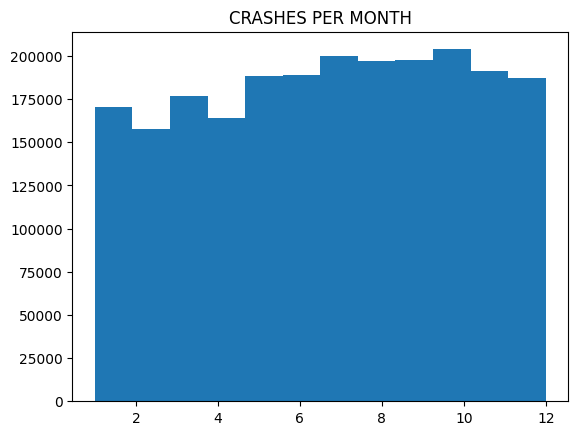

In [57]:
plt.hist(df_cleaned['CRASH MONTH'], 12, histtype='bar')
plt.title('CRASHES PER MONTH')
plt.show()

Az év második felében 25-50 ezerrel több balesetet jegyeztek be, így valamilyen összefüggés látható a balesetek száma és az évszek között, így a hipotézis nem igaz.

##### ***Részletesebb hisztogrammok***

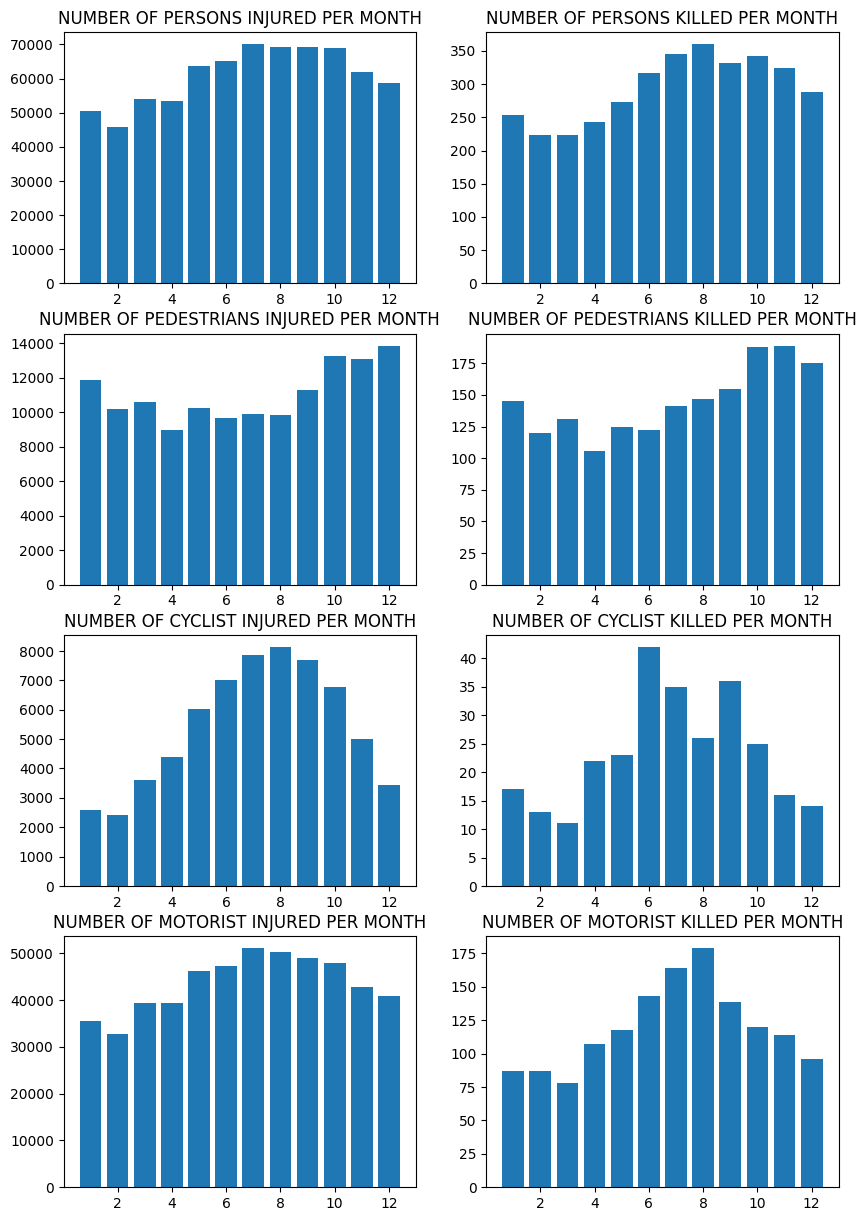

<Figure size 3000x2000 with 0 Axes>

In [58]:
number_of_per_hists('CRASH MONTH')

A hisztogrammokon látható, hogy a gyalogosok télen és ősz végén sérülnek meg gyakrabban, míg a motorosok és a biciklisek tavasz végén, nyáron és ősz elején.

## **2. Hipotézis**

Hipotézis: A COVID járvány hatására jelentősen kevesebb lesz a balesetek száma, viszont ez 2022 után ismét meg fog emelkedni.

Ahhoz hogy ezt megvizsgáljuk évre bontva ábrázolom a balesetek számát hisztogrammon.

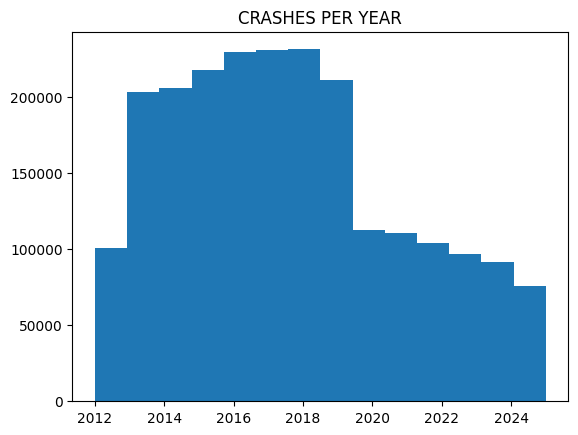

In [59]:
plt.hist(df_cleaned['CRASH YEAR'], df_cleaned['CRASH YEAR'].nunique(), histtype='bar')
plt.title('CRASHES PER YEAR')
plt.show()

In [60]:
df_cleaned['CRASH DATE'].min()

Timestamp('2012-07-01 00:00:00')

Elsőre is lehet látni, hogy 2012-ben nem az év elején kezdődött az adatgyűjtés, ezért ebben az évben jelentősen kevesebb a bejegyzés.

Emellett gyönyörűen látszik a 2020-as COVID járvány hatása is, viszont ami érdekes, hogy a karantén után nem tért vissza a régi értékekhez a balesetek száma, hanem tovább csökkent. Ez megdönti a hipotézist.

##### ***Részletesebb hisztogrammok***

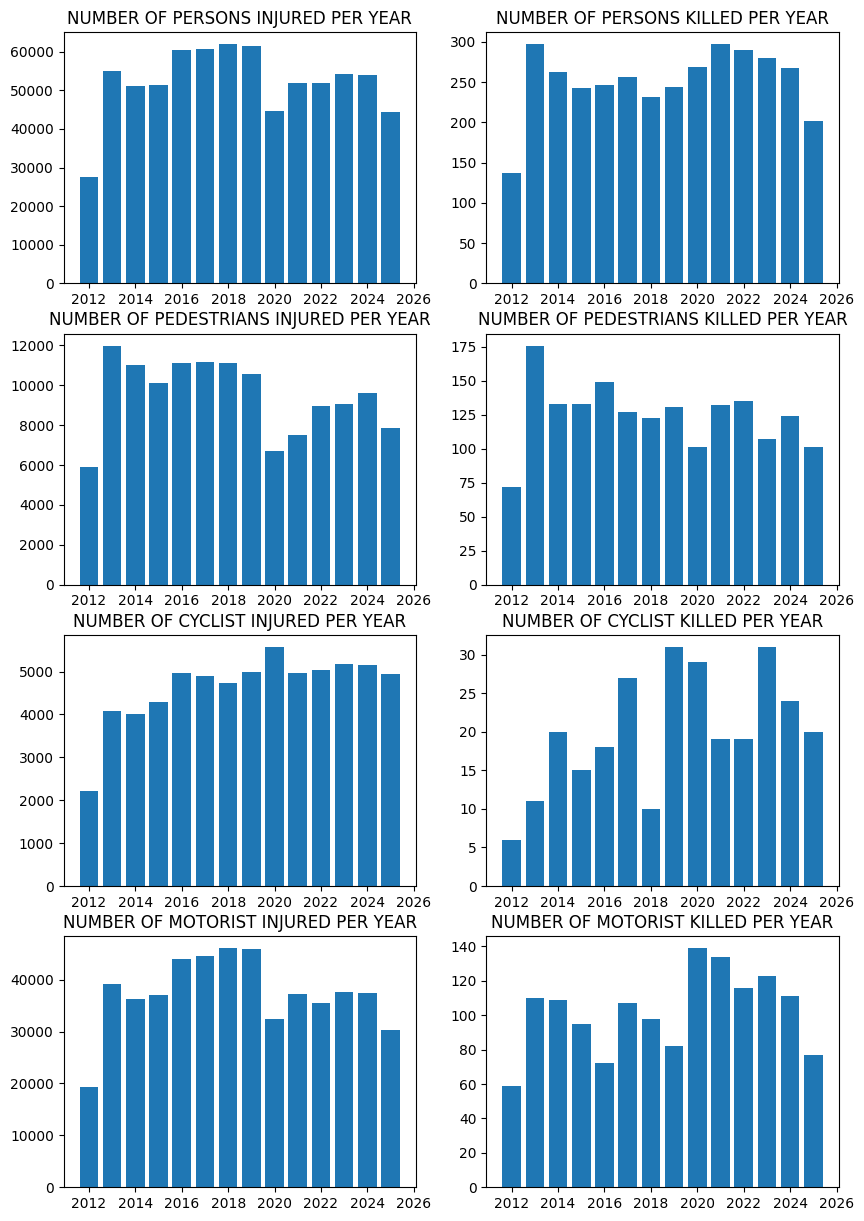

<Figure size 3000x2000 with 0 Axes>

In [61]:
number_of_per_hists('CRASH YEAR')

A 2020 utáni időszakban a gyalogos sérülések szépen lassan elkezdtek emelkedni, de így se érték el a 2020 előtti értékeket.

A sérült biciklisek száma nagyjából állandó maradt.

A motoros sérülések ugyancsak megzuhantak 2020-ban és utána keveset növekedtt, de közel se került a 2020 előtti értékekhez.

Mindez nem magyarázza meg a drasztikus csökkenést a balesetekben, valami más ok állhat mögötte.

## **3. Hipotézis**

Hipotézis: A karambolok és a gépjárművel közlekedő emberek aránya azonos minden kerületben.

In [62]:
cols = ['Bicycle (number)', 'Car, truck, or van (number)', 'Public transportation (number)', 'Walked (number)']

borough_avg = borough_trans.drop(['TimePeriod', 'BoroID'], axis=1)

borough_avg = borough_avg.apply(lambda x: x.replace(r',', value='', regex=True))

for x in cols:
    borough_avg[x] = pd.to_numeric(borough_avg[x], errors='coerce')
    
borough_avg = borough_avg.groupby('Borough').mean(numeric_only=True).reset_index()

borough_avg
    

,Borough,Bicycle (number),"Car, truck, or van (number)",Public transportation (number),Walked (number),Bicycle (percent),"Car, truck, or van (percent)",Public transportation (percent),Walked (percent)
0,Bronx,2119.44444,156244.88889,331350.77778,42567.22222,0.36667,27.83333,59.04444,7.60000
1,Brooklyn,19616.44444,266180.33333,702435.44444,100763.88889,1.67778,22.82222,60.23333,8.65556
2,Manhattan,17038.55556,69325.11111,503395.22222,176878.00000,1.95556,7.93333,57.71111,20.28889
3,Queens,5882.88889,419208.55556,550395.88889,62542.55556,0.52222,38.56667,50.63333,5.75556
4,Staten Island,344.66667,133805.44444,61011.00000,5457.11111,0.16667,64.02222,29.20000,2.61111


In [63]:
crashes_by_borough = df_cleaned['BOROUGH'].value_counts()
crashes_by_borough

BOROUGH
BROOKLYN         494396
QUEENS           413303
MANHATTAN        341747
BRONX            228392
STATEN ISLAND     64588
Name: count, dtype: int64

In [64]:
borough_avg['BOROUGH'] = borough_avg['Borough'].apply(lambda x: x.upper())
merged_df = pd.merge(borough_avg, crashes_by_borough, on='BOROUGH', how='inner')
merged_df['Crashes_to_vehicle_ratio'] = merged_df['count'] / merged_df['Car, truck, or van (number)']
merged_df[['Borough', 'Crashes_to_vehicle_ratio']]

,Borough,Crashes_to_vehicle_ratio
0,Bronx,1.46176
1,Brooklyn,1.85737
2,Manhattan,4.92963
3,Queens,0.98591
4,Staten Island,0.48270


Az arányok nagyon eltérnek egymástól, így a hipotézis nem igaz.

A két leginkább kilógó érték Manhattan és Staten Island, aminek a magyarázata a két kerületben relative nagy, illetve kicsi forgalom lehet.

# **Modellillesztés**

## **A GPS adatok használtával**

In [66]:
X_data = modell_df.drop('BOROUGH', axis=1)
y_data = modell_df['BOROUGH']

In [67]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data,
    test_size=0.2,
    stratify=y_data
)

In [68]:
from sklearn.ensemble import HistGradientBoostingClassifier

MAX_ITERATIONS = 100

hgb_clf_loc = HistGradientBoostingClassifier(
    class_weight='balanced',
    max_iter=MAX_ITERATIONS,
    early_stopping=True,
    verbose=1
)

Azért választottam ezt a modellt, mert jobban teljesít mint a random forest, illetve jelentősen gyorsabb, ami fontos mivel több mint 1 millió soros az adathalmazom. Emellett tudja kezelni a kategorikus adatokat, így nincs szükség preprocessingre.

In [69]:
hgb_clf_loc.fit(X_train, y_train)

Binning 0.160 GB of training data: 0.253 s
Binning 0.018 GB of validation data: 0.017 s
Fitting gradient boosted rounds:
Fit 225 trees in 21.935 s, (6975 total leaves)
Time spent computing histograms: 7.516s
Time spent finding best splits:  0.397s
Time spent applying splits:      2.018s
Time spent predicting:           0.459s


,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dt

In [70]:
y_pred = hgb_clf_loc.predict(X_test)

In [71]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

        BRONX       0.95      0.98      0.96     45678
     BROOKLYN       1.00      0.97      0.98     98879
    MANHATTAN       0.98      0.98      0.98     68350
       QUEENS       0.99      0.98      0.98     82661
STATEN ISLAND       0.85      0.98      0.91     12918

     accuracy                           0.98    308486
    macro avg       0.95      0.98      0.97    308486
 weighted avg       0.98      0.98      0.98    308486



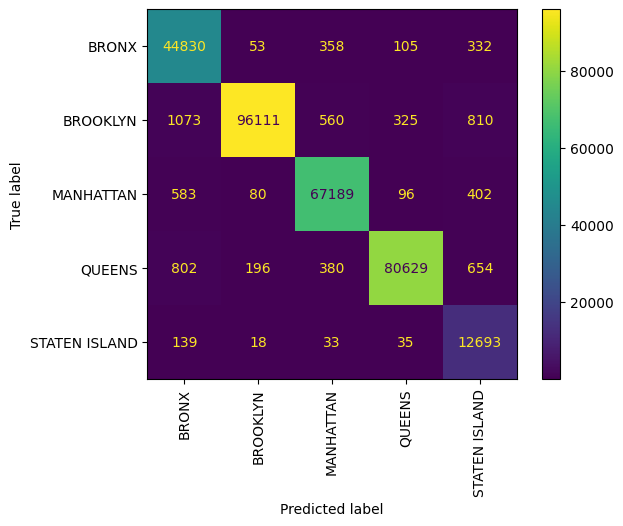

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    hgb_clf_loc, 
    X_test, 
    y_test,
    xticks_rotation='vertical' 
)

plt.show()

## **A GPS adatok nélkül**

### **Hist Gradied Boosting Classifier**

In [73]:
modell_df = modell_df.drop(['LONGITUDE', 'LATITUDE'], axis=1)

In [74]:
X_data = modell_df.drop('BOROUGH', axis=1)
y_data = modell_df['BOROUGH']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data,
    test_size=0.2,
    stratify=y_data
)

In [ ]:
MAX_ITERATIONS = 100

hgb_clf = HistGradientBoostingClassifier(
    class_weight='balanced',
    max_iter=MAX_ITERATIONS,
    early_stopping=True,
    verbose=1
)

In [166]:
hgb_clf.fit(X_train, y_train)

Binning 0.142 GB of training data: 0.294 s
Binning 0.016 GB of validation data: 0.019 s
Fitting gradient boosted rounds:
Fit 500 trees in 55.856 s, (15500 total leaves)
Time spent computing histograms: 27.148s
Time spent finding best splits:  1.627s
Time spent applying splits:      7.236s
Time spent predicting:           2.487s


,loss,'log_loss'
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [167]:
y_pred = hgb_clf.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

        BRONX       0.23      0.30      0.26     45678
     BROOKLYN       0.42      0.15      0.22     98879
    MANHATTAN       0.47      0.49      0.48     68350
       QUEENS       0.38      0.26      0.31     82661
STATEN ISLAND       0.08      0.52      0.14     12918

     accuracy                           0.29    308486
    macro avg       0.32      0.35      0.28    308486
 weighted avg       0.38      0.29      0.30    308486



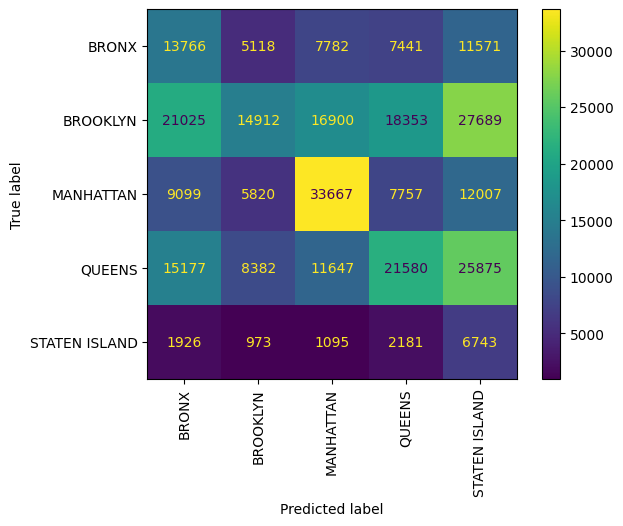

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    hgb_clf, 
    X_test, 
    y_test,
    xticks_rotation='vertical'
)

plt.show()

### **Random Forest**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier

cat_features = ['CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2'] 

# A preprocesszorra azért van szükség, mert a RandomForestClassifier nem kezeli automatikusan a kategórikus változókat
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_features)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced'
)

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf)
])

model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [78]:
y_pred = model_pipeline.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

        BRONX       0.20      0.13      0.16     45678
     BROOKLYN       0.36      0.43      0.39     98879
    MANHATTAN       0.42      0.43      0.43     68350
       QUEENS       0.33      0.34      0.33     82661
STATEN ISLAND       0.10      0.05      0.07     12918

     accuracy                           0.34    308486
    macro avg       0.28      0.28      0.28    308486
 weighted avg       0.33      0.34      0.34    308486



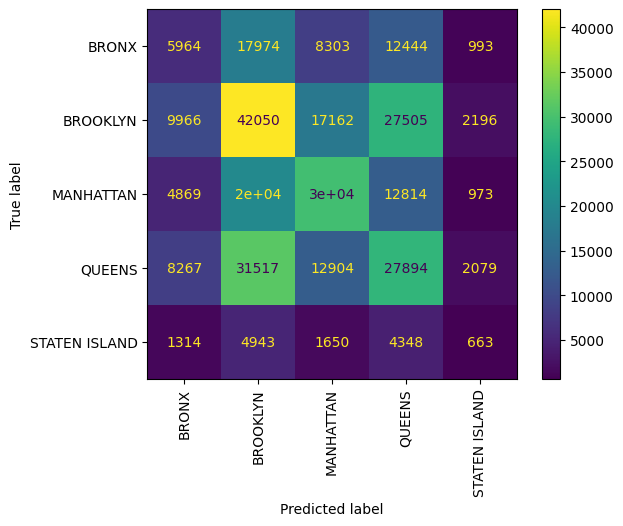

In [80]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    model_pipeline, 
    X_test, 
    y_test,
    xticks_rotation='vertical' 
)

plt.show()

### **Uundersampling**

In [83]:
min_class_len = modell_df['BOROUGH'].value_counts().min()
balanced_modell_df = modell_df.groupby('BOROUGH').sample(n=min_class_len).reset_index(drop=True)

In [90]:
X_data = balanced_modell_df.drop('BOROUGH', axis=1)
y_data = balanced_modell_df['BOROUGH']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data,
    test_size=0.2,
    stratify=y_data
)

In [ ]:
MAX_ITERATIONS = 100

hgb_clf_bal = HistGradientBoostingClassifier(
    class_weight='balanced',
    max_iter=MAX_ITERATIONS,
    early_stopping=True,
    verbose=1
)

hgb_clf_bal.fit(X_train, y_train)

Binning 0.030 GB of training data: 0.075 s
Binning 0.003 GB of validation data: 0.002 s
Fitting gradient boosted rounds:
Fit 460 trees in 6.978 s, (14260 total leaves)
Time spent computing histograms: 2.589s
Time spent finding best splits:  0.399s
Time spent applying splits:      0.996s
Time spent predicting:           0.171s


,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dt

               precision    recall  f1-score   support

        BRONX       0.30      0.30      0.30     12918
     BROOKLYN       0.28      0.15      0.20     12917
    MANHATTAN       0.46      0.48      0.47     12918
       QUEENS       0.29      0.26      0.27     12917
STATEN ISLAND       0.34      0.51      0.41     12918

     accuracy                           0.34     64588
    macro avg       0.33      0.34      0.33     64588
 weighted avg       0.33      0.34      0.33     64588



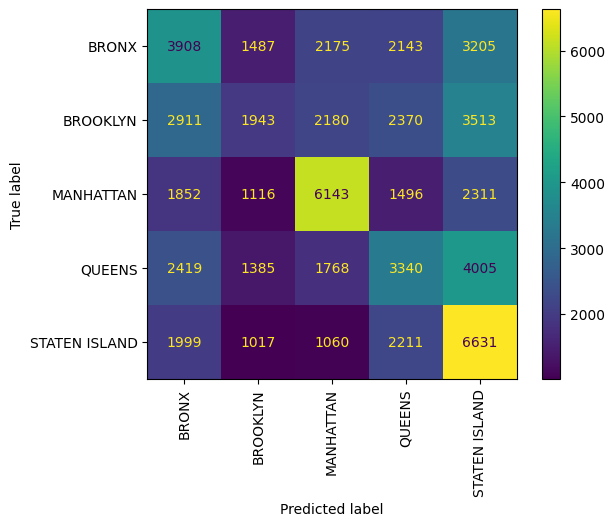

In [93]:
y_pred = hgb_clf_bal.predict(X_test)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(
    hgb_clf_bal, 
    X_test, 
    y_test,
    xticks_rotation='vertical'
)

plt.show()

# **A modell értékelése**

Ha a modellnek odaadom a GPS adatokat, akkor minden kerületnél több mint 90%os pontosságot ért el a modell.

Sajnos, ha elveszem tőle a GPS adatokat drasztikusan romlik a teljesítmény. és 52% a legjobb elért eredmény. 

A rossz eredményel láttán teszteltem a random forest modellt is, ami hasonlóan rosszul teljesített, ugyan más kerületekre adott pontosabb predikciót.

Utolsó probálkozásként manuálisan megpróbáltam kiegyensúlyozni a minták számát, de sajnos ez sem ért el jelntős változást az eredényekben.

Ebből azt a következtetést vonom le, hogy sajnos nincs függ eléggé a többi adattol,hogy melyi kerületben tatlálható a baleset, így nem tudok a prediktálására megbízható modellt építeni a GPS adatok felhasználása nélkül.

# **Egyéb érdekes megfigyelések**

## **Sérülések**

### **A hét napjaira bontva**

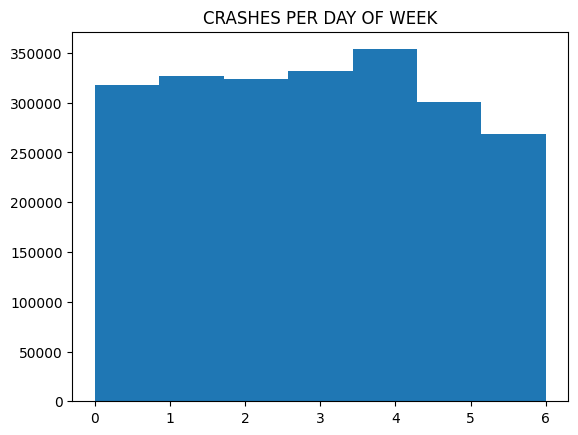

In [68]:
plt.hist(df_cleaned['CRASH DAY OF WEEK'], 7, histtype='bar')
plt.title('CRASHES PER DAY OF WEEK')
plt.show()

Hétközben több baleset történik, ami lehet annak köszönhető, hogy ilyenkor az emberek munkába járnak.

##### Sérülések és halálozások elsozlása a hét napjai szerint

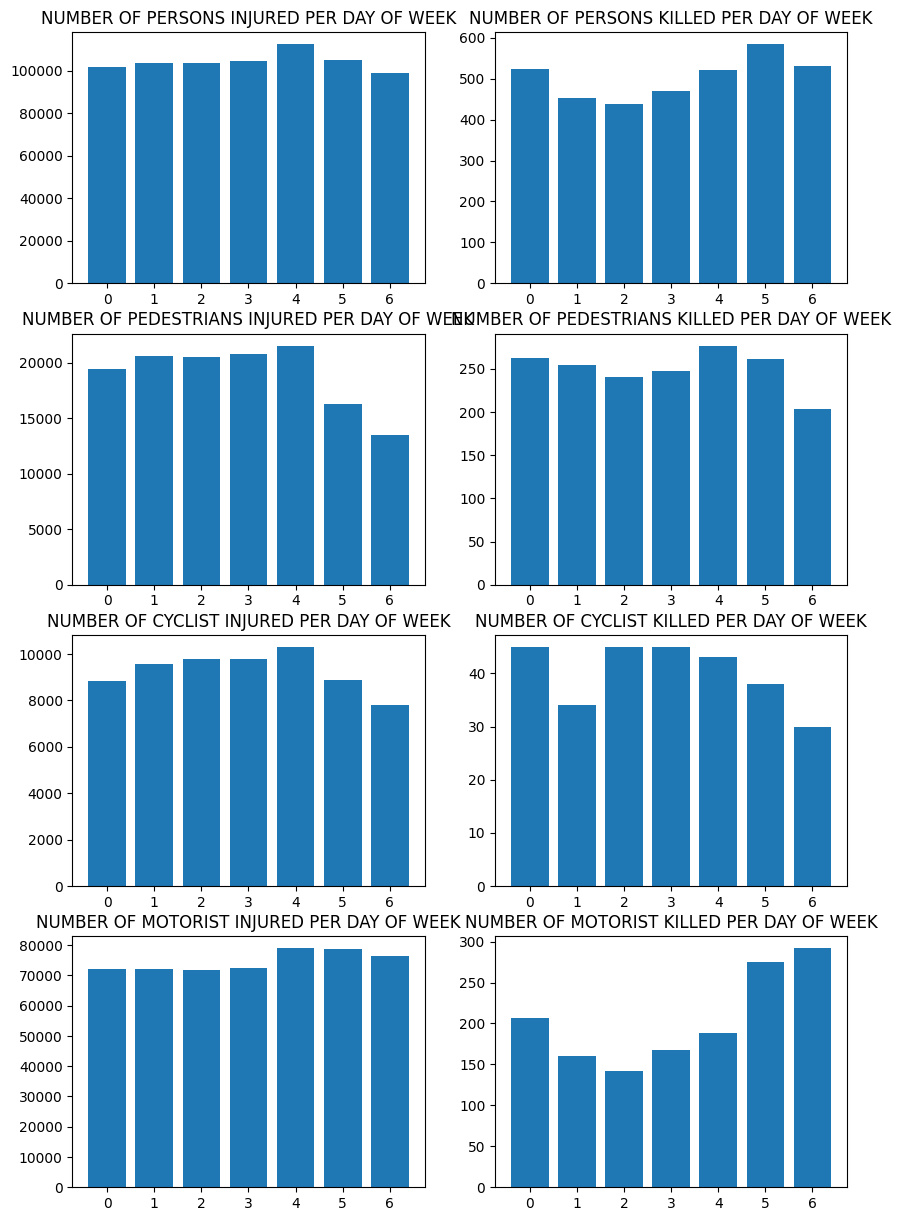

<Figure size 3000x2000 with 0 Axes>

In [69]:
number_of_per_hists('CRASH DAY OF WEEK')

### **A nap órájától függően**

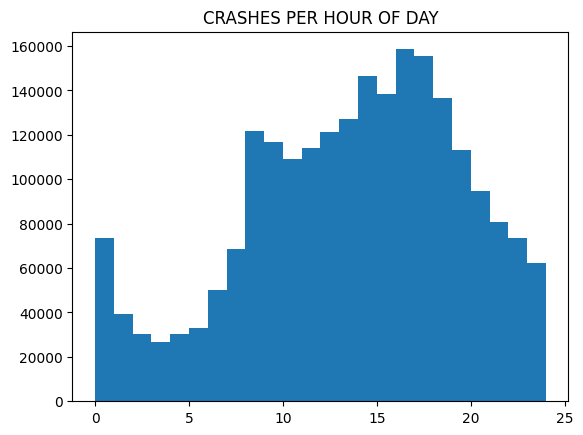

In [70]:
plt.hist(df_cleaned['CRASH TIME OF DAY'], 24, histtype='bar')
plt.title('CRASHES PER HOUR OF DAY')
plt.show()

##### Sérülések és halálozások eloszlása a nap órája alapján

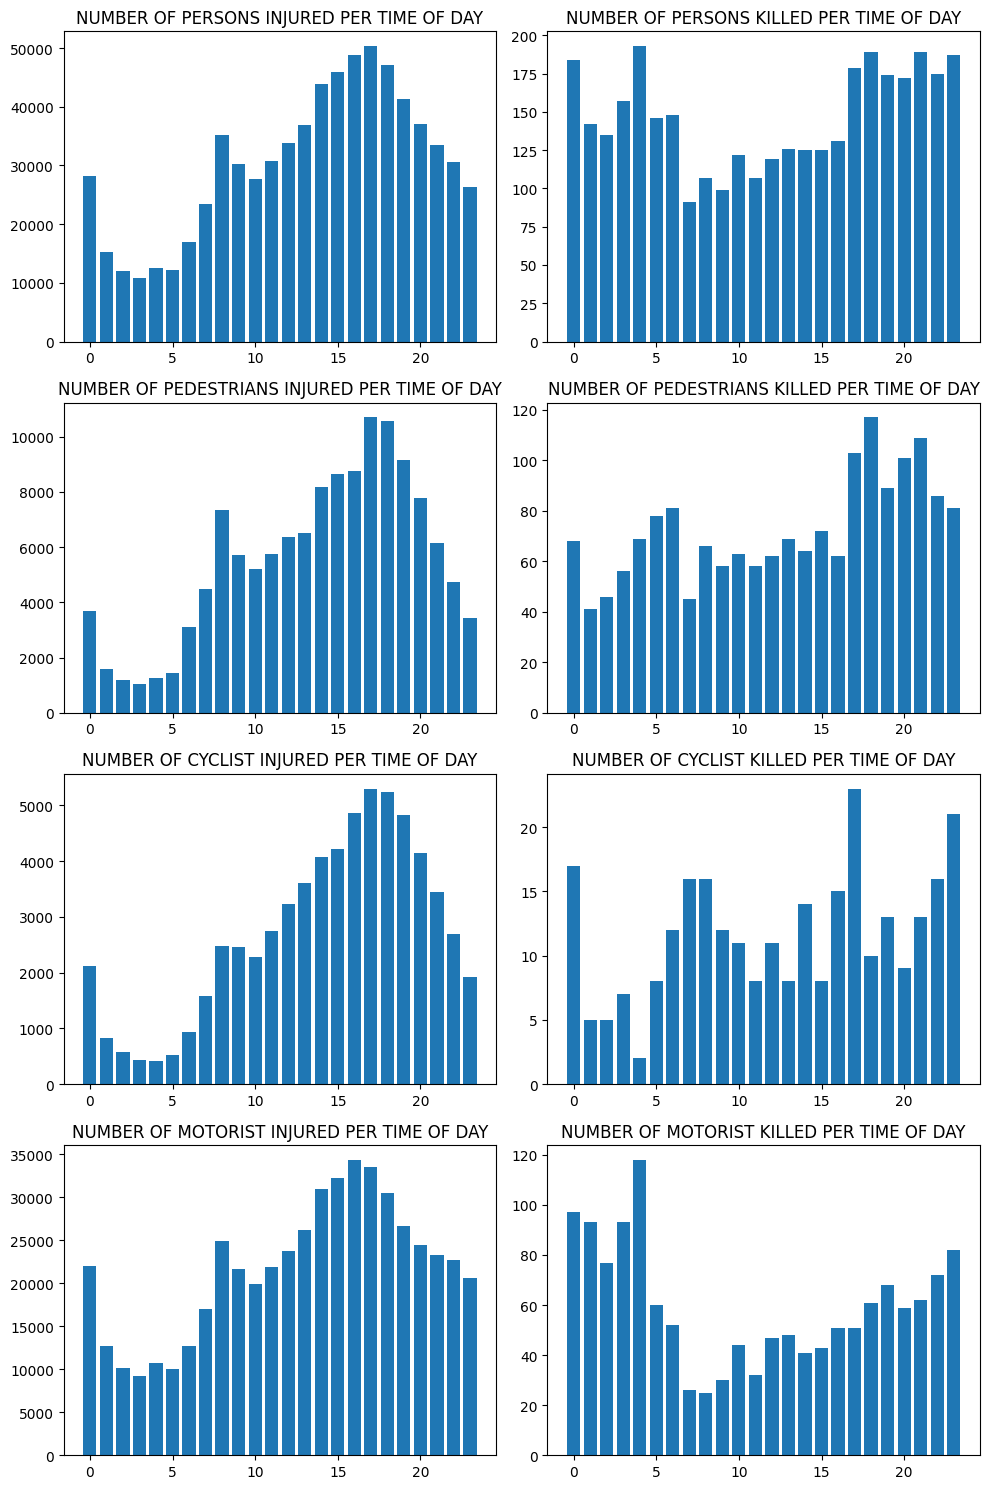

<Figure size 3000x2000 with 0 Axes>

In [71]:
fig, ((ax0, ax1), (ax2, ax3), (ax4, ax5), (ax6, ax7)) = plt.subplots(nrows=4, ncols=2, figsize = (10,15))
plt.figure(figsize = (30,20))

colName = 'CRASH TIME OF DAY'

plots = [ax0, ax1, ax2, ax3, ax4, ax5, ax6, ax7]

cols = df_cleaned.filter(regex='NUMBER').columns

tmp_df = df_cleaned.filter(regex= colName + '|NUMBER').copy(deep=True)
tmp_df[colName] = tmp_df[colName].apply(lambda x: math.floor(x))
tmp_df = tmp_df.groupby(colName).sum()

for i, col in enumerate(cols):
    plot = plots[i]
    plot.bar(tmp_df[col].index, tmp_df[col])
    plot.set_title(col + ' PER ' + colName.replace('CRASH ', ''))
    
fig.tight_layout()
plt.show()